In [7]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import tensorflow.keras.backend as K

# 1: load the chronologically partitioned and scaled datasets 
data_dir = 'Model_Ready_Data_Agus1'

df_train = pd.read_csv(os.path.join(data_dir, 'Train.csv'), index_col='Time', parse_dates=True, dayfirst=True)
df_val = pd.read_csv(os.path.join(data_dir, 'Validation.csv'), index_col='Time', parse_dates=True, dayfirst=True)
df_calib = pd.read_csv(os.path.join(data_dir, 'Calibration.csv'), index_col='Time', parse_dates=True, dayfirst=True)
df_test = pd.read_csv(os.path.join(data_dir, 'Test.csv'), index_col='Time', parse_dates=True, dayfirst=True)

target_col_name = 'Total_Power' 
target_idx = df_train.columns.get_loc(target_col_name)

# 2: define the sliding window function to generate temporal sequences
def create_sequences(data, target_index, lookback, horizon=1):
    X, y = [], []
    data_array = data.values 
    for i in range(len(data_array) - lookback - horizon + 1):
        X_seq = data_array[i : (i + lookback), :]
        y_target = data_array[i + lookback + horizon - 1, target_index]
        X.append(X_seq)
        y.append(y_target)
    return np.array(X), np.array(y)

LOOKBACK = 96  # 24 hours of memory
HORIZON = 1    # 15 mins into the future

X_train, y_train = create_sequences(df_train, target_idx, LOOKBACK, HORIZON)
X_val, y_val = create_sequences(df_val, target_idx, LOOKBACK, HORIZON)
X_calib, y_calib = create_sequences(df_calib, target_idx, LOOKBACK, HORIZON)
X_test, y_test = create_sequences(df_test, target_idx, LOOKBACK, HORIZON)

# #: configure the custom dual-quantile pinball loss function 
QUANTILES = [0.05, 0.95]

def pinball_loss(y_true, y_pred):

    y_true_expanded = tf.expand_dims(y_true, axis=-1)
 
    q_lower = QUANTILES[0]
    err_lower = y_true_expanded - y_pred[:, 0:1]
    loss_lower = K.maximum(q_lower * err_lower, (q_lower - 1) * err_lower)

    q_upper = QUANTILES[1]
    err_upper = y_true_expanded - y_pred[:, 1:2]
    loss_upper = K.maximum(q_upper * err_upper, (q_upper - 1) * err_upper)
    
    return K.mean(loss_lower + loss_upper)
    
# 4: construct the 2-stacked LSTM architecture 
n_timesteps = X_train.shape[1] 
n_features = X_train.shape[2]

model = Sequential()
model.add(Input(shape=(n_timesteps, n_features)))

model.add(LSTM(units=64, return_sequences=True))
model.add(Dropout(0.2)) 

model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))

# 5: compile the model with two output neurons for the upper and lower prediction bounds
model.add(Dense(units=2))
model.compile(optimizer='adam', loss=pinball_loss)

model.summary()

TensorFlow Version: 2.20.0
Starting CQR Phase 2: LSTM Sequence Generation and Architecture...

Creating sequences (Lookback: 96 steps)...

Building the CQR Neural Network...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 96, 64)              │          18,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 96, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,170 (121.76 KB)

 Trainable params: 31,170 (121.76 KB)

 Non-trainable params: 0 (0.00 B)

Starting CQR Model Training...
Epoch 1/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 74s 69ms/step - loss: 0.0449 - val_loss: 0.0339
Epoch 2/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 66s 67ms/step - loss: 0.0355 - val_loss: 0.0311
Epoch 3/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 66s 67ms/step - loss: 0.0331 - val_loss: 0.0285
Epoch 4/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 66s 67ms/step - loss: 0.0318 - val_loss: 0.0282
Epoch 5/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 68s 69ms/step - loss: 0.0307 - val_loss: 0.0277
Epoch 6/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 66s 68ms/step - loss: 0.0302 - val_loss: 0.0265
Epoch 7/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 65s 66ms/step - loss: 0.0301 - val_loss: 0.0265
Epoch 8/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 66s 67ms/step - loss: 0.0299 - val_loss: 0.0267
Epoch 9/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 66s 67ms/step - loss: 0.0296 - val_loss: 0.0261
Epoch 10/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 67s 68ms/step - loss: 0.0293 - val_loss: 0.0264
Epoch 11/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 67s 68ms/step - loss: 0.0294 - val_loss: 0.0262

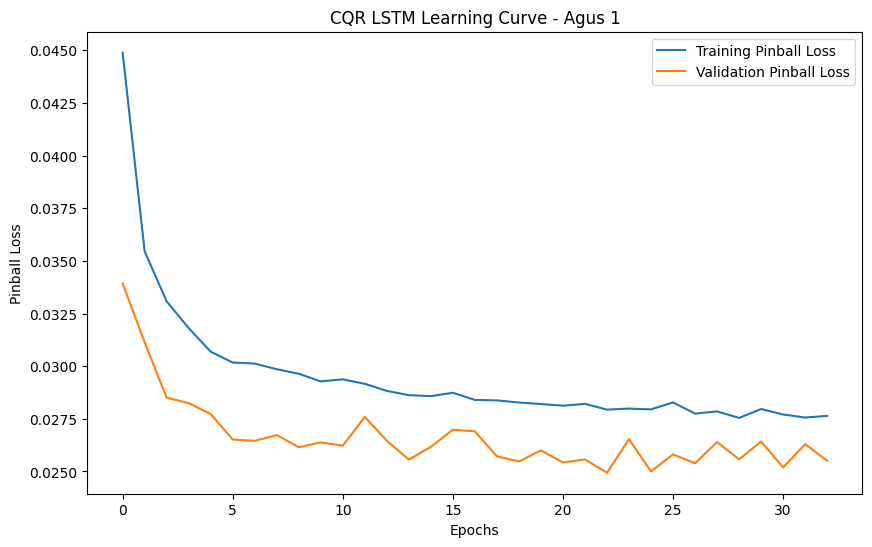

In [8]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 1: configure early stopping mechanism to prevent overfitting 
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 2: execte model training using the custom pinball loss funtion
history = model.fit(
    X_train, y_train,
    epochs=50,          
    batch_size=32,      
    validation_data=(X_val, y_val), 
    callbacks=[early_stop],         
    verbose=1           
)

# 3: visualize the learning curve to verify convergence
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Pinball Loss')
plt.plot(history.history['val_loss'], label='Validation Pinball Loss')
plt.title('CQR LSTM Learning Curve - Agus 1')
plt.xlabel('Epochs')
plt.ylabel('Pinball Loss')
plt.legend()
plt.show()

In [9]:
from sklearn.preprocessing import RobustScaler
import numpy as np

# 1: reconstruct the robust scaler using strictly the training partition
original_df = pd.read_csv('Processed_Agus1_Dataset.csv', index_col='Time', parse_dates=True, dayfirst=True)
features = original_df.columns.tolist()
train_end = int(len(original_df) * 0.60)

scaler = RobustScaler()
scaler.fit(original_df.iloc[:train_end][features])

# 2: execute model inference to generate raw dual-quantile predictions
calib_preds = model.predict(X_calib) 
test_preds = model.predict(X_test)

# 3: define function to inverse transform the normalized quantiles back into MW
def unscale_cqr(preds, actuals):
    dummy_act = np.zeros((len(actuals), len(features)))
    dummy_lower = np.zeros((len(preds), len(features)))
    dummy_upper = np.zeros((len(preds), len(features)))

    dummy_act[:, 0] = actuals
    dummy_lower[:, 0] = preds[:, 0] # Neuron 0 (5th percentile)
    dummy_upper[:, 0] = preds[:, 1] # Neuron 1 (95th percentile)

    real_act = scaler.inverse_transform(dummy_act)[:, 0]
    real_low = scaler.inverse_transform(dummy_lower)[:, 0]
    real_up = scaler.inverse_transform(dummy_upper)[:, 0]
    
    return real_act, real_low, real_up

real_y_calib, real_low_calib, real_up_calib = unscale_cqr(calib_preds, y_calib)
real_y_test, real_low_test, real_up_test = unscale_cqr(test_preds, y_test)

# 4: align results with chronological timestamps and export raw bounds for Phase 3 calibration
dates_calib = df_calib.index[LOOKBACK + HORIZON - 1:]
dates_test = df_test.index[LOOKBACK + HORIZON - 1:]

calib_df = pd.DataFrame({'Time': dates_calib, 'Actual_MW': real_y_calib, 'CQR_Lower_MW': real_low_calib, 'CQR_Upper_MW': real_up_calib})
calib_df.to_csv('Agus1_CQR_Calib.csv', index=False)

test_df = pd.DataFrame({'Time': dates_test, 'Actual_MW': real_y_test, 'CQR_Lower_MW': real_low_test, 'CQR_Upper_MW': real_up_test})
test_df.to_csv('Agus1_CQR_Test.csv', index=False)

Predicting and un-scaling CQR bounds back to Megawatts (MW)...
244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step
244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step
SUCCESS! CQR calibration and test bounds safely saved.


Image successfully saved as 'CQR_Quantile_Steps.png'!


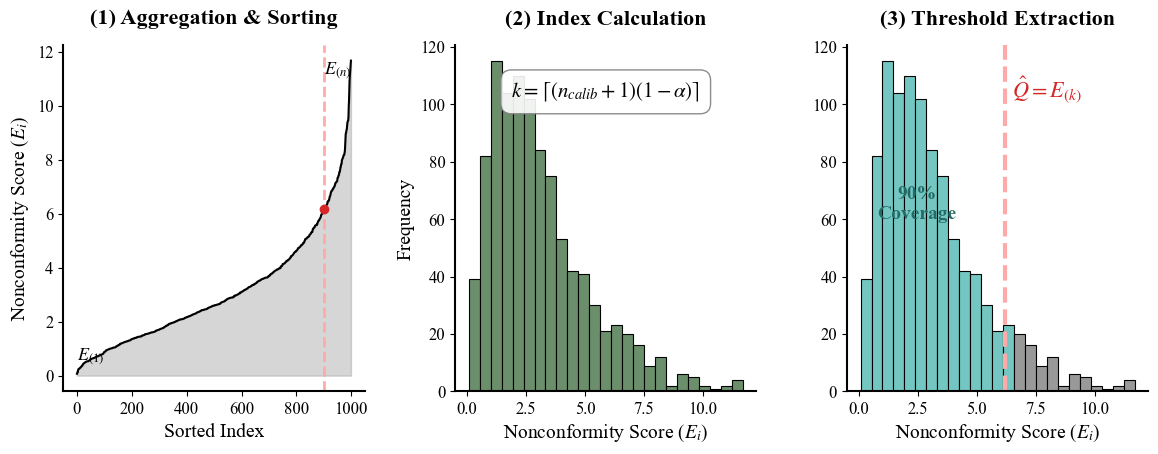

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Set global font to match academic thesis style (Times New Roman)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix' # Best mathtext font for Times New Roman

# ==========================================
# 1. GENERATE CALIBRATION DATA
# ==========================================
np.random.seed(42)
n_calib = 1000
alpha = 0.10

# Simulate typical nonconformity scores (bounded at 0, with a right tail)
scores = np.random.gamma(shape=2.0, scale=1.5, size=n_calib)

# Step 1 Math: Sort the scores
sorted_scores = np.sort(scores)

# Step 2 Math: Finite-Sample Index
k = math.ceil((n_calib + 1) * (1 - alpha))

# Step 3 Math: Extract Threshold (k-1 because Python is 0-indexed)
Q_hat = sorted_scores[k - 1]

# ==========================================
# 2. SETUP THE FIGURE
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
plt.subplots_adjust(wspace=0.3)

# Define exact colors from the reference image
color_grey = '#999999'
color_green = '#6b8e6b'
color_teal = '#73c6c1'
color_pink = '#ffaaaa'

# ==========================================
# PANEL 1: Aggregation and Sorting
# ==========================================
axes[0].fill_between(range(n_calib), sorted_scores, color=color_grey, alpha=0.4)
axes[0].plot(range(n_calib), sorted_scores, color='black', linewidth=1.5)
axes[0].set_title('(1) Aggregation & Sorting', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Sorted Index', fontsize=14)
axes[0].set_ylabel('Nonconformity Score ($E_i$)', fontsize=14)

# Annotate the start, end, and the k-index extraction point
axes[0].text(0, sorted_scores[0] + 0.5, '$E_{(1)}$', ha='left', fontsize=13)
axes[0].text(n_calib, sorted_scores[-1] - 0.5, '$E_{(n)}$', ha='right', fontsize=13)

# Highlight the extraction point
axes[0].axvline(k, color=color_pink, linestyle='--', linewidth=2)
axes[0].plot(k, Q_hat, 'o', color='#d62728', markersize=6) # Red dot at extraction

# ==========================================
# PANEL 2: Finite-Sample Index
# ==========================================
axes[1].hist(scores, bins=25, color=color_green, edgecolor='black', linewidth=0.8)
axes[1].set_title('(2) Index Calculation', fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('Nonconformity Score ($E_i$)', fontsize=14)
axes[1].set_ylabel('Frequency', fontsize=14)

# Display the mathematical formula for k
math_text = r'$k = \lceil (n_{calib} + 1)(1 - \alpha) \rceil$'
axes[1].text(0.5, 0.85, math_text, transform=axes[1].transAxes, 
             fontsize=15, ha='center', bbox=dict(facecolor='white', edgecolor='grey', boxstyle='round,pad=0.5', alpha=0.9))

# ==========================================
# PANEL 3: Threshold Extraction
# ==========================================
n_counts, bins, patches = axes[2].hist(scores, bins=25, edgecolor='black', linewidth=0.8)

# Color the bars: Teal for covered (<= Q_hat), Grey for uncovered (> Q_hat)
for i in range(len(patches)):
    if bins[i] < Q_hat:
        patches[i].set_facecolor(color_teal)
    else:
        patches[i].set_facecolor(color_grey)

# Draw the threshold line
axes[2].axvline(Q_hat, color=color_pink, linestyle='--', linewidth=3)
axes[2].set_title('(3) Threshold Extraction', fontsize=16, fontweight='bold', pad=15)
axes[2].set_xlabel('Nonconformity Score ($E_i$)', fontsize=14)

# Annotations for Q_hat and the 90% Area
axes[2].text(Q_hat + 0.3, axes[2].get_ylim()[1] * 0.85, r'$\hat{Q} = E_{(k)}$', 
             color='#d62728', fontsize=16, fontweight='bold')
axes[2].text(Q_hat * 0.4, axes[2].get_ylim()[1] * 0.5, '90%\nCoverage', 
             ha='center', fontsize=14, color='#246b66', fontweight='bold')

# ==========================================
# 3. GLOBAL STYLING & EXPORT
# ==========================================
# Clean up spines (borders) to match the reference style
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12)

# Save the figure
plt.savefig('CQR_Quantile_Steps.png', dpi=700, bbox_inches='tight')
print("Image successfully saved as 'CQR_Quantile_Steps.png'!")

Image successfully saved as 'Data_Analysis_Flowchart.png'!


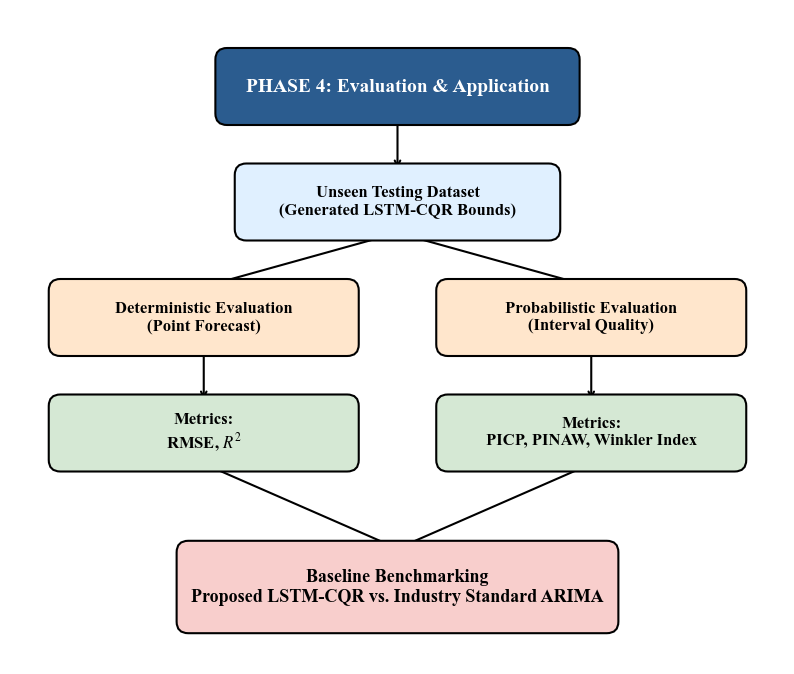

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Set global font to match academic thesis style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

fig, ax = plt.subplots(figsize=(10, 8.5))
ax.axis('off')

# Helper function to draw boxes
def draw_box(ax, x, y, width, height, text, facecolor, edgecolor='black', text_color='black', fontsize=12, weight='bold'):
    box = patches.FancyBboxPatch((x - width/2, y - height/2), width, height, 
                                 boxstyle="round,pad=0.1,rounding_size=0.15", 
                                 facecolor=facecolor, edgecolor=edgecolor, linewidth=1.5, zorder=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, weight=weight, color=text_color, zorder=3)

# Helper function to draw arrows
def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color="black", lw=1.5), zorder=1)

# --- Define Coordinates ---
y_top = 7.5
y_data = 6.0
y_split = 4.5
y_metrics = 3.0
y_bench = 1.0

x_center = 5
x_left = 2.5
x_right = 7.5

# --- Draw Boxes ---
# 1. Phase Header (Dark Blue)
draw_box(ax, x_center, y_top, 4.5, 0.8, "PHASE 4: Evaluation & Application", '#2b5c8f', text_color='white', fontsize=14)

# 2. Testing Set (Light Blue)
draw_box(ax, x_center, y_data, 4.0, 0.8, "Unseen Testing Dataset\n(Generated LSTM-CQR Bounds)", '#e0f0ff')

# 3. Split Tracks (Orange/Yellow for distinction)
draw_box(ax, x_left, y_split, 3.8, 0.8, "Deterministic Evaluation\n(Point Forecast)", '#ffe6cc')
draw_box(ax, x_right, y_split, 3.8, 0.8, "Probabilistic Evaluation\n(Interval Quality)", '#ffe6cc')

# 4. Metrics (Green for scoring)
draw_box(ax, x_left, y_metrics, 3.8, 0.8, "Metrics:\nRMSE, $R^2$", '#d5e8d4')
draw_box(ax, x_right, y_metrics, 3.8, 0.8, "Metrics:\nPICP, PINAW, Winkler Index", '#d5e8d4')

# 5. Baseline Benchmarking (Red/Pink for final showdown)
draw_box(ax, x_center, y_bench, 5.5, 1.0, "Baseline Benchmarking\nProposed LSTM-CQR vs. Industry Standard ARIMA", '#f8cecc', fontsize=13)

# --- Draw Arrows ---
# Top to Data
draw_arrow(ax, x_center, y_top - 0.4, x_center, y_data + 0.4)

# Data to Split Tracks
draw_arrow(ax, x_center, y_data - 0.4, x_left, y_split + 0.4)
draw_arrow(ax, x_center, y_data - 0.4, x_right, y_split + 0.4)

# Split to Metrics
draw_arrow(ax, x_left, y_split - 0.4, x_left, y_metrics + 0.4)
draw_arrow(ax, x_right, y_split - 0.4, x_right, y_metrics + 0.4)

# Metrics to Benchmarking
draw_arrow(ax, x_left, y_metrics - 0.4, x_center, y_bench + 0.5)
draw_arrow(ax, x_right, y_metrics - 0.4, x_center, y_bench + 0.5)

# --- Set Limits and Save ---
ax.set_xlim(0, 10)
ax.set_ylim(0, 8.5)

plt.savefig("Data_Analysis_Flowchart.png", dpi=1000, bbox_inches='tight')
print("Image successfully saved as 'Data_Analysis_Flowchart.png'!")